# gpt2_basic_training_abstracts
## 2026JAN20


# 0. DETECTION OF GOOGLE DRIVE AND SETUP PATHS  
Some basics for detection of whether using google drive and colaboratory.  
Strong recommend to do this - very easy setup and much faster operation using a GPU (T4 GPU as of January 2026). See README.md for installation instructions.

Inspect the various path variables (PROJECT_ROOT, DATA_DIR, OUTPUT_DIR, SRC_DIR) if there are problems.

In [1]:
# CELL 1: Optional Google Drive mount (Colab only)
import os
from pathlib import Path

def in_colab() -> bool:
    return "COLAB_GPU" in os.environ or "COLAB_TPU_ADDR" in os.environ or "google.colab" in str(getattr(__import__("sys"), "modules", {}))

IN_COLAB = in_colab()

if IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
        print("Mounted Google Drive at /content/drive")
    except Exception as e:
        print(f"Could not mount Google Drive: {e}")
else:
    print("Not running in Colab; skipping Drive mount.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive at /content/drive


In [2]:

# CELL 2: Resolve PROJECT_ROOT (env override > Colab Drive default > search from cwd)
import os
import sys
from pathlib import Path

env_root = os.environ.get("LLM_PROJECT_ROOT", "").strip()
default_colab_root = Path("/content/drive/MyDrive/llm-from-scratch-drive")

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src").exists():
            return p
    return start

if env_root:
    PROJECT_ROOT = Path(env_root).expanduser().resolve()
elif default_colab_root.exists():
    PROJECT_ROOT = default_colab_root.resolve()
else:
    PROJECT_ROOT = find_repo_root(Path.cwd().resolve())

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC exists:", (PROJECT_ROOT / "src").exists())


CWD: /content
PROJECT_ROOT: /content/drive/MyDrive/llm-from-scratch-drive
SRC exists: True


## 1. package loading

In [3]:
# CELL 3: Imports
import json
from copy import deepcopy
from datetime import datetime

import torch
import torch.nn as nn
import tiktoken
import pickle

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from torch.utils.data import Dataset, DataLoader



## 2. setup paths for llm package load

In [4]:

# CELL 4: Paths + sys.path + project imports
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

# Create output dir if missing (safe)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("SRC_DIR:", SRC_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

# Add src to import path (notebook-friendly)
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Now your imports work locally or in Colab
from llm_from_scratch.configs import gpt2small_config
from llm_from_scratch.training import training_utils
from llm_from_scratch.models import gpt2
from llm_from_scratch.dataloader import dataloader


SRC_DIR: /content/drive/MyDrive/llm-from-scratch-drive/src
DATA_DIR: /content/drive/MyDrive/llm-from-scratch-drive/data
OUTPUT_DIR: /content/drive/MyDrive/llm-from-scratch-drive/output


## 3. setup run_training() and load_pretrained_model()

In [5]:
def run_training(cfg):
    """Run a single training experiment given a config dict."""


    start = datetime.now()
    debug_flag = True # True means that a lot of extra info is output

    # copy cfg
    cfg = deepcopy(cfg)  # avoid in-place mutation
    model_cfg = cfg['model_config']

    # use best device
    device = cfg['device_name']
    print("DEVICE: initial device before adjustment:",device)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("DEVICE: device AFTER adjustment:",str(device))
    cfg['device_name'] = str(device)

    # set seed
    torch.manual_seed(cfg['seed'])

    # print cfg
    print(cfg)

    # establish model
    model = gpt2.setup_model(model_cfg)
    model.to(device)
    totparams = sum(p.numel() for p in model.parameters())
    print("Total number of parameters:", totparams)

    # setup tokenizer
    tokenizer = tiktoken.get_encoding(cfg['tokenizer'])



    # This path currently targets GPT-2 small weights
    if cfg['load_pretrained_params']:
      cfg['params_file']=str(DATA_DIR) + "/gpt2_openai_params_124M.pkl"
      fullnm = cfg['params_file']
      with open(fullnm, "rb") as f:
          params = pickle.load(f)
      if debug_flag:
        print(params.keys())
        print(params['wpe'].shape)
      training_utils.load_weights_into_gpt(model, params)
      model.out_head.weight = model.tok_emb.weight # weight tying here
      model.to(device)
      if debug_flag:
        print("2. weight_tying flag:", model_cfg["weight_tying"])
        print("2. same object?:", model.out_head.weight is model.tok_emb.weight)
        print("2. out_head.weight shape:", model.out_head.weight.shape)
        print("2. tok_emb.weight shape:", model.tok_emb.weight.shape)

      # print a single example
      print("pretrain example:")
      training_utils.generate_and_print_sample(model,cfg, tokenizer, device, cfg['start_context'])

    # setup dataloaders
    train_loader, val_loader, test_loader = dataloader.generate_data_loaders(cfg)
    print("Show train_loader first entry (converted to text):")
    dataloader.loader_text_examine(train_loader, 0, tokenizer)
    print("Show val_loader first entry (converted to text):")
    dataloader.loader_text_examine(val_loader, 0, tokenizer)
    if test_loader is not None:
        print("Show test_loader first entry (converted to text):")
        dataloader.loader_text_examine(test_loader, 0, tokenizer)

    # show loss before training
    print("BEFORE TRAINING:")
    before_res = training_utils.eval_full_sets(model, train_loader, val_loader, device, do_train=True)

    # model training
    model.train()
    num_epochs = cfg['num_epochs']
    optimizer = training_utils.setup_optimizer(model, cfg)
    train_losses, val_losses, tokens_seen, global_step = training_utils.train_model_simple(
        model=model,
        cfg=cfg,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=cfg['device_name'],
        num_epochs=cfg['num_epochs'],
        eval_freq=cfg['eval_freq'],
        eval_iter=cfg['eval_iter'],
        save_freq=cfg['save_freq'],
        start_context=cfg['start_context'],
        tokenizer=tokenizer
    )

    # plot train and validation loss curves
    epochs_tensor = torch.linspace(0, cfg['num_epochs'], len(train_losses))
    training_utils.plot_losses(cfg, epochs_tensor, tokens_seen, train_losses, val_losses)

    # save configuration
    training_utils.save_cfg_json(
        cfg=cfg,
        epoch=num_epochs,
        global_step=global_step)

    # save results
    training_utils.save_results(cfg,
        train_losses, val_losses, tokens_seen, global_step)

    # print post-training results
    print("AFTER TRAINING:")
    after_res = training_utils.eval_full_sets(model, train_loader, val_loader, device, do_train=True)

    # calculate run time and print
    end = datetime.now()
    elapsed = end - start
    total_seconds = int(elapsed.total_seconds())
    hours, rem = divmod(total_seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    runtime_formatted = f"{hours:02d}:{minutes:02d}:{seconds:02d}"
    print(f"Runtime: {runtime_formatted}")

    # print summary of results
    resdict = {
        "initial_train_loss_full_set": float(before_res[0]),
        "initial_val_loss_full_set": float(before_res[1]),
        "final_train_loss_full_set": float(after_res[0]),
        "final_val_loss_full_set": float(after_res[1]),
        "tokens_seen": int(tokens_seen[-1]),
        "global_step": int(global_step),
        "runtime": runtime_formatted
    }
    print(resdict)

    return model

def load_pretrained_model(cfg):
    """Just load a pretrained model.
    cfg: specifies model parameters for model setup
    Note that pretrained check is included here
    Returns model loaded with weights
    """

    start = datetime.now()
    debug_flag = True # True means that a lot of extra info is output
    cfg = deepcopy(cfg)  # avoid in-place mutation
    model_cfg = cfg['model_config']

    device = cfg['device_name']
    print("DEVICE: initial device before adjustment:",device)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("DEVICE: device AFTER adjustment:",str(device))
    cfg['device_name'] = str(device)

    torch.manual_seed(cfg['seed'])

    print(cfg)
    model = gpt2.setup_model(model_cfg)
    model.to(device)
    totparams = sum(p.numel() for p in model.parameters())
    print("Total number of parameters:", totparams)


    if debug_flag:
      print("weight_tying flag:", model_cfg["weight_tying"])
      print("same object?:", model.out_head.weight is model.tok_emb.weight)
      print("out_head.weight shape:", model.out_head.weight.shape)
      print("tok_emb.weight shape:", model.tok_emb.weight.shape)

    tokenizer = tiktoken.get_encoding(cfg['tokenizer'])

    # This path currently targets GPT-2 small weights
    if cfg['load_pretrained_params']:
      cfg['params_file']=str(DATA_DIR) + "/gpt2_openai_params_124M.pkl"
      fullnm = cfg['params_file']
      with open(fullnm, "rb") as f:
          params = pickle.load(f)
      if debug_flag:
        print(params.keys())
        print(params['wpe'].shape)
      training_utils.load_weights_into_gpt(model, params)
      model.to(device)

      print("pretrain example:")
      training_utils.generate_and_print_sample(model,cfg, tokenizer, device, cfg['start_context'])

    return model



## 4. EXPERIMENT: Domain-adaptive pretraining with basic params with small ("test") abstract file, 1 epoch

### configs

In [6]:
cfg = gpt2small_config.RUN_CONFIG
cfg
cfg2 = deepcopy(cfg)


cfg2['model_config']= gpt2small_config.GPT_CONFIG_124M_OPENAI
cfg2['run_name'] = "gpt2_temp_continualpretrain_TEST_abstracts_FULL_TEST_FULL_VAL"
cfg2['description'] = "FULL TEST AND VALIDATION SET"
cfg2['load_pretrained_params']=True


cfg2['num_epochs']=1 # Short validation run
cfg2['batch_size']=2
cfg2['stride']=1024


cfg2['eval_freq']=20
cfg2['eval_iter']=20
cfg2['start_context']="HER2 is important for breast cancer because"


cfg2['device_name'] = "cuda"
cfg2['save_overwrite']= True # When True, overwrite the prior checkpoint for this run name


cfg2['training_file'] = str(DATA_DIR) + "/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt"
cfg2['val_file'] = str(DATA_DIR) + "/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_val_abstracts.txt"
#cfg2['training_file'] = str(DATA_DIR) + "/the-verdict.txt"  # for testing purposes
print(cfg2['training_file'])


cfg2['output_dir'] = str(OUTPUT_DIR)
print(cfg2['output_dir'])

print(cfg2)


/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt
/content/drive/MyDrive/llm-from-scratch-drive/output
{'run_name': 'gpt2_temp_continualpretrain_TEST_abstracts_FULL_TEST_FULL_VAL', 'description': 'FULL TEST AND VALIDATION SET', 'device_name': 'cuda', 'model_name': 'gpt2-small', 'model_config': {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True, 'weight_tying': True}, 'tokenizer': 'gpt2', 'load_pretrained_params': True, 'params_file': '/home/markb/llm-from-scratch/data/gpt2_params.pkl', 'training_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt', 'start_context': 'HER2 is important for breast cancer because', 'val_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_val_abst

### load weights into model and extract token embedding layer

In [7]:
model_before = load_pretrained_model(cfg2)


DEVICE: initial device before adjustment: cuda
DEVICE: device AFTER adjustment: cuda
{'run_name': 'gpt2_temp_continualpretrain_TEST_abstracts_FULL_TEST_FULL_VAL', 'description': 'FULL TEST AND VALIDATION SET', 'device_name': 'cuda', 'model_name': 'gpt2-small', 'model_config': {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True, 'weight_tying': True}, 'tokenizer': 'gpt2', 'load_pretrained_params': True, 'params_file': '/home/markb/llm-from-scratch/data/gpt2_params.pkl', 'training_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt', 'start_context': 'HER2 is important for breast cancer because', 'val_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_val_abstracts.txt', 'test_file': '', 'val_ratio': 0.1, 'test_ratio': 0.0, 'stride': 1024, 'batch_size': 2, '

### run model

DEVICE: initial device before adjustment: cuda
DEVICE: device AFTER adjustment: cuda
{'run_name': 'gpt2_temp_continualpretrain_TEST_abstracts_FULL_TEST_FULL_VAL', 'description': 'FULL TEST AND VALIDATION SET', 'device_name': 'cuda', 'model_name': 'gpt2-small', 'model_config': {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True, 'weight_tying': True}, 'tokenizer': 'gpt2', 'load_pretrained_params': True, 'params_file': '/home/markb/llm-from-scratch/data/gpt2_params.pkl', 'training_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_test_abstracts.txt', 'start_context': 'HER2 is important for breast cancer because', 'val_file': '/content/drive/MyDrive/llm-from-scratch-drive/data/pubmed_abstracts_2005to2025ONLY_ERBB2_ABSTRACTS_getv7_english_val_abstracts.txt', 'test_file': '', 'val_ratio': 0.1, 'test_ratio': 0.0, 'stride': 1024, 'batch_size': 2, '

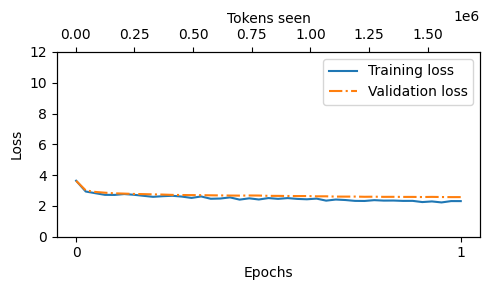

Saved cfg to /content/drive/MyDrive/llm-from-scratch-drive/output/gpt2_temp_continualpretrain_TEST_abstracts_FULL_TEST_FULL_VAL/epoch001_step0000819_cfg.json
Saved results to /content/drive/MyDrive/llm-from-scratch-drive/output/gpt2_temp_continualpretrain_TEST_abstracts_FULL_TEST_FULL_VAL/epoch001_step0000819_results.json
AFTER TRAINING:
FULL train loss: 2.2619776990355516
FULL val loss: 2.5513388674433637
Runtime: 00:28:33
{'initial_train_loss_full_set': 2.9261843533050724, 'initial_val_loss_full_set': 2.9232817001459077, 'final_train_loss_full_set': 2.2619776990355516, 'final_val_loss_full_set': 2.5513388674433637, 'tokens_seen': 1640448, 'global_step': 819, 'runtime': '00:28:33'}


In [8]:
model_after = run_training(cfg2)